# <ins>**MODELE LOF**</ins>

**Pour rappel, une valeur aberrante (ou outlier en anglais) est un point différent ou éloigné du reste des données. L’objectif est d’identifier les valeurs aberrantes qui sont présentes dans un jeu de données, pour ainsi détecter des anomalies.**

**Le Local Outlier Factor (LOF) est un algorithme non-supervisé qui identifie les valeurs aberrantes locales présentes dans un jeu de données. Mais qu'entend-on par "valeur aberrante locale" ? Lorsqu'un point est considéré comme aberrant sur la base de son voisinage local, alors il s'agit d'une valeur aberrante. L’algorithme LOF identifie une valeur aberrante locale en fonction de la densité du voisinage de cette valeur. Il donne de bons résultats lorsque la densité des données n'est pas la même dans l'ensemble du jeu de données.**

In [9]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score,matthews_corrcoef, classification_report,roc_curve
from sklearn.preprocessing import MinMaxScaler
from pathlib import Path
import logging

### **1. Lecture de notre datasets**

In [22]:
# Chemin des fichiers
data_dir = Path("../data/raw/bronze/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

df = pd.read_csv(data_dir)

df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


### **2. Nettoyage du dataset**

In [23]:
def clean_column_network_data(df):
    """
    Nettoie les données réseau brutes du CICIDS2017

    Args:
        pd.DataFrame brute

    Returns:
        pd.DataFrame: DataFrame nettoyé et prêt pour l'analyse
    """
    # Configuration du logging
    logging.basicConfig(level=logging.INFO)

    try:
        # Nettoyage des noms de colonnes
        def clean_column_names(df):
            df.columns = (df.columns.str.strip()
                            .str.lower()
                            .str.replace('[^a-z0-9_]', '_', regex=True))
            return df
        df = clean_column_names(df)

        # Mapping des labels
        condition1 = df['label']=='BENIGN'
        condition2 = df['label']!='BENIGN'

        df.loc[condition1, 'label'] = 0
        df.loc[condition2, 'label'] = 1

        # Suppression des outliers astronomiques
        df = df.astype(float)
        df = df[np.isfinite(df).all(axis=1)]
        max_float32 = np.finfo(np.float32).max
        df = df[np.abs(df)<max_float32]

        # Suppression des lignes avec NaN après encodage et doublons
        initial_shape = df.shape[0]
        df = df.dropna()
        # Suppression des doublons réseau critiques
        df = df.drop_duplicates()
        final_shape = df.shape[0]

        logging.info(f"Données nettoyées : {final_shape} lignes restantes ({initial_shape - final_shape} lignes supprimées)")

        return df

    except Exception as e:
        logging.error(f"Erreur lors du nettoyage : {str(e)}")
        raise

df = clean_column_network_data(df)

INFO:root:Données nettoyées : 223082 lignes restantes (2629 lignes supprimées)


In [12]:
# séparation des variables
y = df['label']
y = y.astype('int')
X = df.drop('label', axis = 1)

In [16]:
minmax = MinMaxScaler()
X = minmax.fit_transform(X)

In [49]:
pca = PCA(n_components=0.95)  # Conserve 95% de variance
principalComponents = pca.fit_transform(X)

principalDf = pd.DataFrame(data = principalComponents, columns = ['principal component 1', 'principal component 2'])
finalDf = pd.concat([principalDf, y], axis = 1)
finalDf.head()

,principal component 1,principal component 2,label
0,-0.869192,-0.289146,0.0
1,-1.042252,-0.173296,0.0
2,-1.042281,-0.173312,0.0
3,-1.026439,-0.187021,0.0
4,-0.869190,-0.289149,0.0


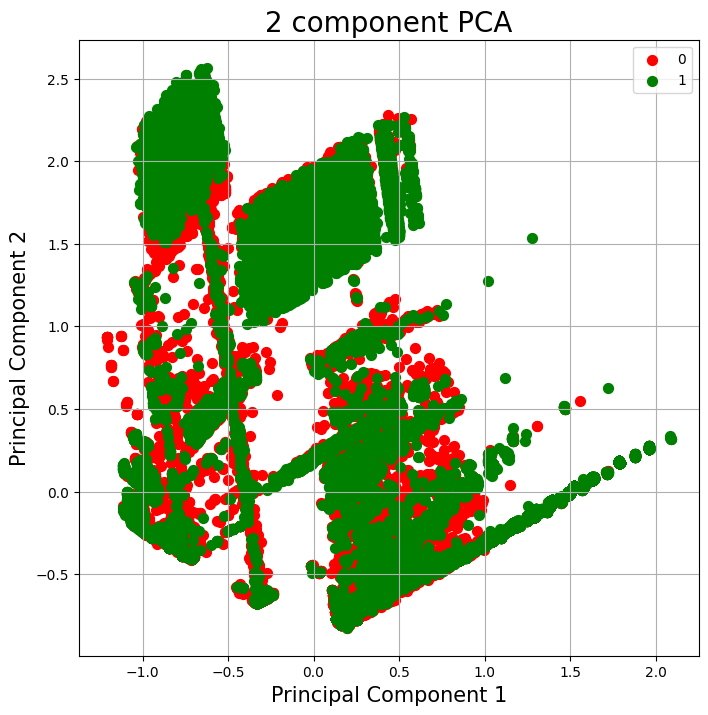

In [ ]:
fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(1,1,1)
ax.set_xlabel('Principal Component 1', fontsize = 15)
ax.set_ylabel('Principal Component 2', fontsize = 15)
ax.set_title('2 component PCA',
fontsize = 20)
targets = [0, 1]
colors = ['r', 'g']
for target, color in zip(targets,colors):
    indicesToKeep = finalDf['label'] == target
    ax.scatter(finalDf.loc[indicesToKeep, 'principal component 1'],
                finalDf.loc[indicesToKeep, 'principal component 2'],
                c = color,
                s = 50)
ax.legend(targets)
ax.grid()

In [50]:
finalDf = finalDf.dropna()

X = finalDf.drop('label', axis = 1)

y = finalDf['label']

In [51]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.42)

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2)

lof.fit(X_train,y_train)

y_pred = lof.fit_predict(X_test)

# Remarque 2 : L'algorithme LOF renvoie la valeur -1 pour les outliers prédits et la valeur 1 sinon.
y_pred[y_pred == 1] = 0
y_pred[y_pred == -1] = 1

print("Score entrainement accuracy obtenu : ", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Score entrainement accuracy obtenu :  0.45347191610792753
              precision    recall  f1-score   support

         0.0       0.38      0.54      0.44     17441
         1.0       0.56      0.39      0.46     25662

    accuracy                           0.45     43103
   macro avg       0.47      0.47      0.45     43103
weighted avg       0.49      0.45      0.45     43103



In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score
print("Matrice de confusion:\n", confusion_matrix(y_test, y_pred))
print("#"*50)
print("ROC-AUC SCORE:", roc_auc_score(y_test, y_pred))
print("#"*50)
print("MCC Score:", matthews_corrcoef(y_test, y_pred))
print("#"*50)
print("Precision-recall Score:",
average_precision_score(y_test, y_pred))

Matrice de confusion:
 [[ 9442  7999]
 [15558 10104]]
##################################################
ROC-AUC SCORE: 0.46755098323608324
##################################################
MCC Score: -0.06453825204441335
##################################################
Precision-recall Score: 0.5807078240028538
